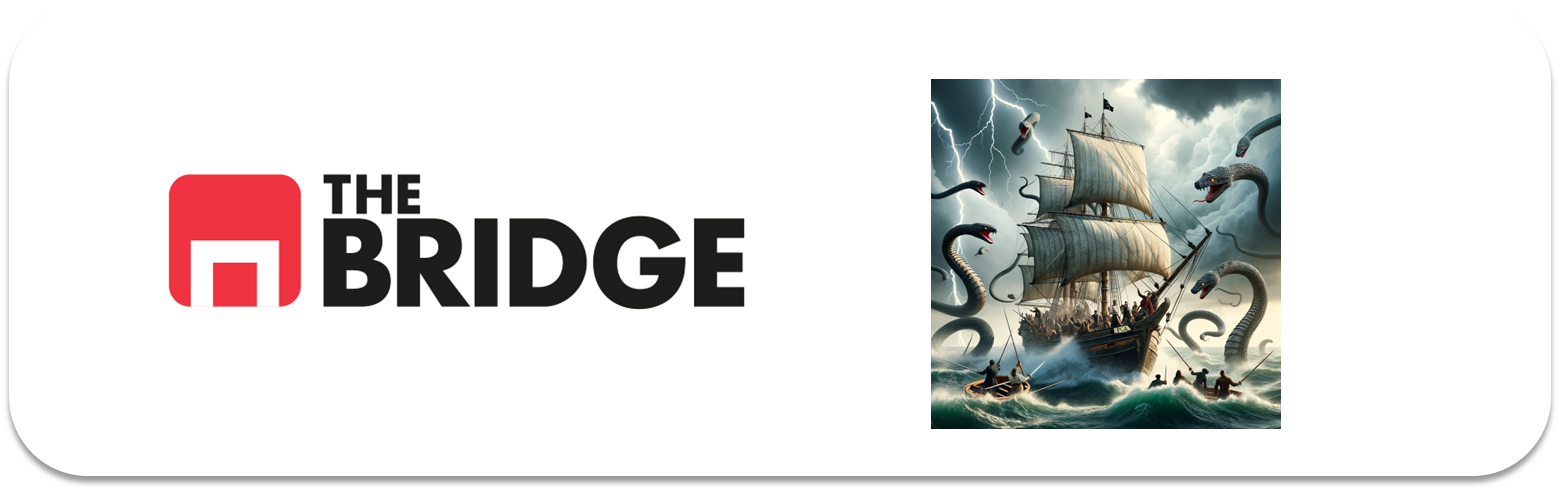

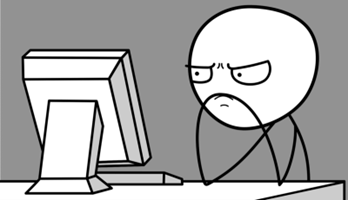

Para ejercitarte y afianzar lo aprendido sobre **Seleccion de Features**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

## Feature selection: Breast Cancer Winsconsin

El objetivo de este grupo de ejercicio es dar a entender la importancia de la selección de características (features), así como probar distintos métodos de reducción de características (features) y qué influencia puede tener el reducir features en el perfomance de un modelo. Nuestro target para evaluar el perfomance será si estamos ante tumores malignos o benignos.

Vamos a trabajar con el dataset de Breast Cancer Winsconsin, datos tomados a partir de radiografías.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

from scipy import stats
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV


### Ejercicio 1:

Carga los datos y haz una primera inspección de los mismos y comenta lo que creas conveniente sobre las features y su relación entre sí (pero sin analizarlas numéricamente)

In [2]:
df = pd.read_csv("./data/breastcancer-winsconsin.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### Ejercicio 2:

Descarta las características que evidentemente no aportan información.

In [4]:
df = df.drop(columns=["id", "Unnamed: 32"])

print(df.shape)
print(df.head)

(569, 31)
<bound method NDFrame.head of     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0           M        17.99         10.38          122.80     1001.0   
1           M        20.57         17.77          132.90     1326.0   
2           M        19.69         21.25          130.00     1203.0   
3           M        11.42         20.38           77.58      386.1   
4           M        20.29         14.34          135.10     1297.0   
..        ...          ...           ...             ...        ...   
564         M        21.56         22.39          142.00     1479.0   
565         M        20.13         28.25          131.20     1261.0   
566         M        16.60         28.08          108.30      858.1   
567         M        20.60         29.33          140.10     1265.0   
568         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0            0.11840        

### Ejercicio 3: 

Divide en train y test. Analiza el target de forma breve.

In [5]:
target = 'diagnosis'
X = df.drop(columns=target)
y = df[target]

df[target].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Ejercicio 4: MiniEDA (I) Análisis Visual

Realiza un análisis visual de las features y haz tu selección de primera "división" (que luego usaremos para comparar con otros métodos de selección).

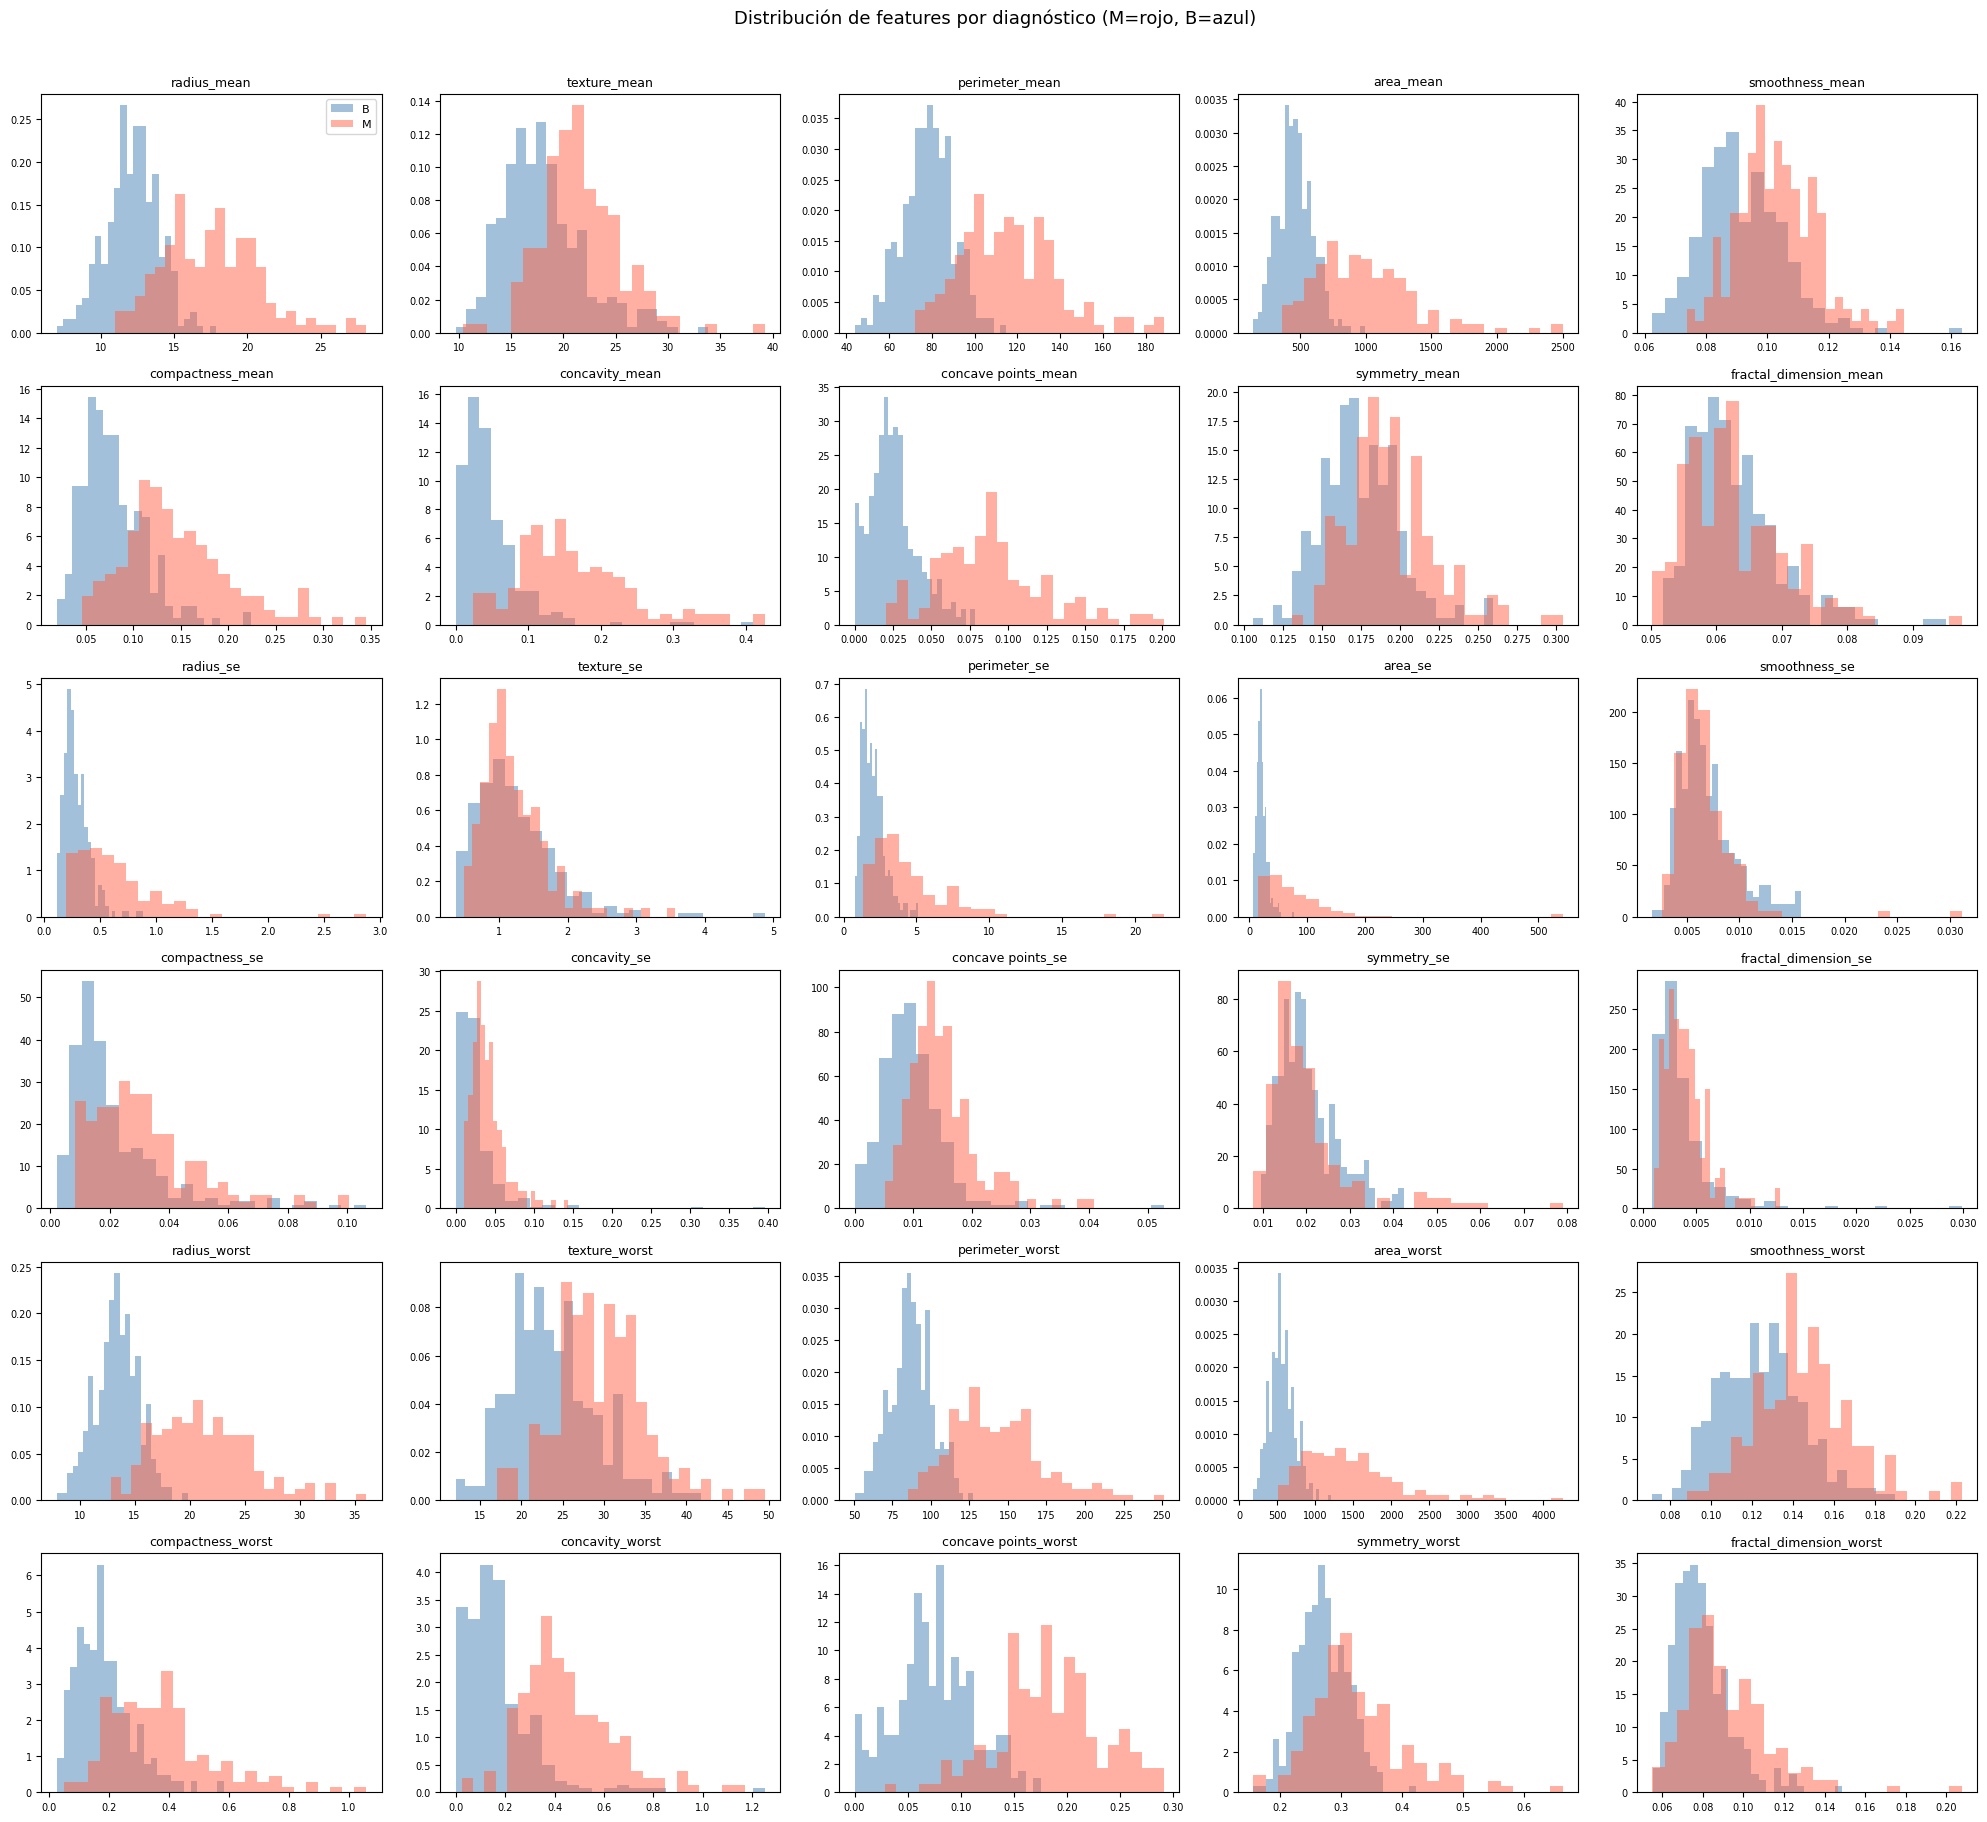

In [7]:
features = X_train.columns.tolist()

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    for label, color in zip(["B", "M"], ["steelblue", "tomato"]):
        subset = X_train[y_train == label][col]
        axes[i].hist(subset, bins=25, alpha=0.5, label=label, color=color, density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=7)

axes[0].legend(fontsize=8)
plt.suptitle("Distribución de features por diagnóstico (M=rojo, B=azul)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# Primera división: separación clara y limpia
features_primera_division = [
    "radius_mean", "perimeter_mean", "area_mean",
    "concavity_mean", "concave points_mean",
    "radius_worst", "perimeter_worst", "area_worst",
    "concavity_worst", "concave points_worst"
]

# Segunda prioridad: desplazamiento visible pero con solapamiento notable
features_segunda_division = [
    "smoothness_mean", "symmetry_mean", "concave points_se"
]

X_train_visual = X_train[features_primera_division]
X_test_visual  = X_test[features_primera_division]

print(f"Primera división: {len(features_primera_division)} features")
print(f"Segunda división: {len(features_segunda_division)} features (reservadas)")

Primera división: 10 features
Segunda división: 3 features (reservadas)


### Ejercicio 5

Observa correlaciones entre las features. Utiliza un gráfico apropiado para ello. ¿Crees que sea posible eliminar algunas features para mejorar el modelo? (No hace falta que lo hagas ahora, lo haremos si es necesario en un ejercicio posterior)

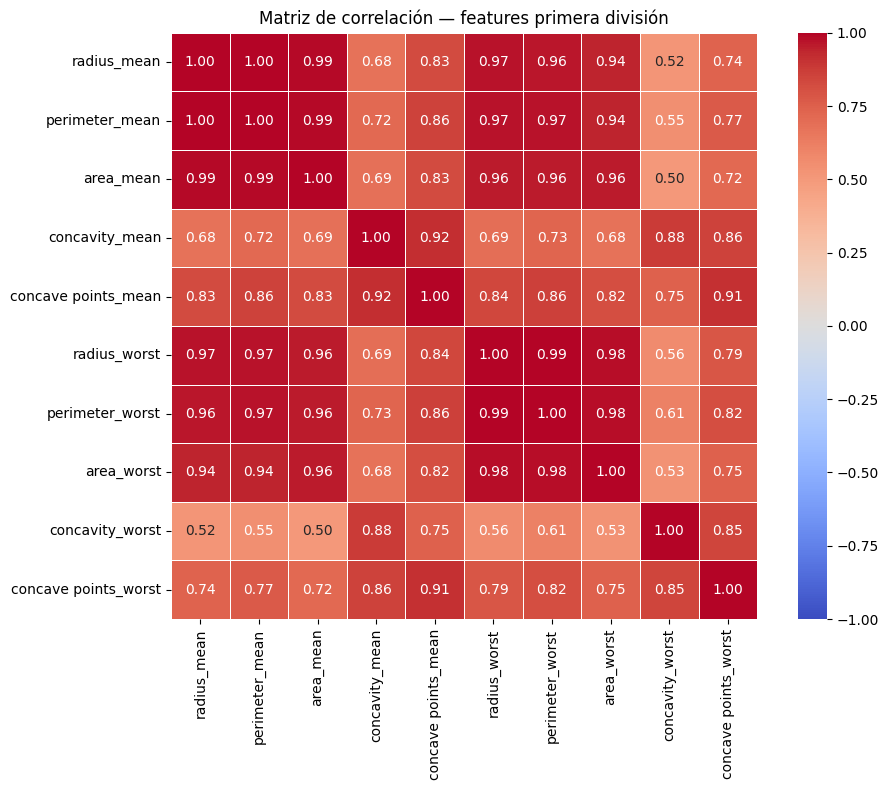

In [9]:
corr = X_train[features_primera_division].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title("Matriz de correlación — features primera división", fontsize=12)
plt.tight_layout()
plt.show()

### Ejercicio 6:

Entrena (con validación cruzada) un modelo de RandomForestClassifier (con max_depth a 5) con todas las features (ojo incluso las que descartamos en el ejercicio 4) y guarda el perfomance ("balanced_accuracy") en test en una variable. Será nuestro base line de comparación

In [10]:
rf_baseline = RandomForestClassifier(max_depth=5, random_state=42)

cv_baseline = cross_validate(
 rf_baseline,
 X_train, y_train,
 cv=5,
 scoring="balanced_accuracy",
 return_train_score=True
)

print("=== BASELINE — 30 features ===")
print(f"Train balanced_accuracy: {cv_baseline['train_score'].mean():.4f} ± {cv_baseline['train_score'].std():.4f}")
print(f"Val   balanced_accuracy: {cv_baseline['test_score'].mean():.4f} ± {cv_baseline['test_score'].std():.4f}")

=== BASELINE — 30 features ===
Train balanced_accuracy: 0.9904 ± 0.0050
Val   balanced_accuracy: 0.9507 ± 0.0304


In [11]:
# Score en test — nuestro baseline de comparación
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)
baseline_score = balanced_accuracy_score(y_test, y_pred_baseline)

print(f"\nTest balanced_accuracy (baseline): {baseline_score:.4f}")



Test balanced_accuracy (baseline): 0.9643


### Ejercicio 7

Vamos a emplear nuestras features del análisis visual pero descartando variables correladas entre sí (emplea la matriz ya obtenida en el ejercicio 5 o bien cualquier medio que creas conveniente). Descarta features y muestra la matriz de correlación para la selección final (recuerda, parte de la lista creada en el ejercicio 4)

In [12]:
features_visual_final = [
    "area_mean",
    "concave points_mean",
    "area_worst",
    "concave points_worst"
]

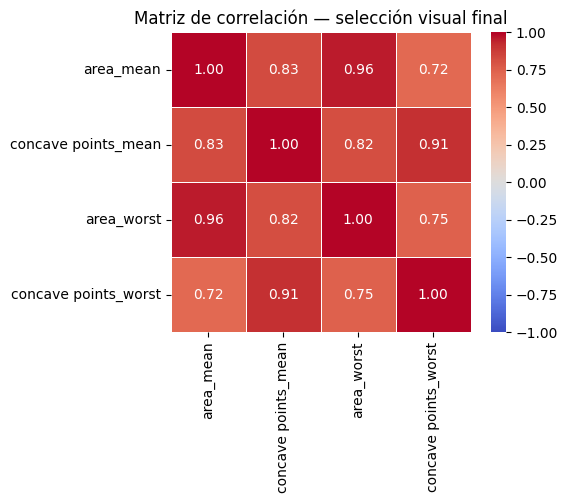

Features seleccionadas: 4
['area_mean', 'concave points_mean', 'area_worst', 'concave points_worst']


In [13]:
# Matriz de correlación de la selección final
corr_final = X_train[features_visual_final].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_final, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title("Matriz de correlación — selección visual final", fontsize=12)
plt.tight_layout()
plt.show()

X_train_visual = X_train[features_visual_final]
X_test_visual  = X_test[features_visual_final]

print(f"Features seleccionadas: {len(features_visual_final)}")
print(features_visual_final)

In [14]:
X_train_visual = X_train[features_visual_final]
X_test_visual  = X_test[features_visual_final]

print(f"Features seleccionadas: {len(features_visual_final)}")
print(features_visual_final)

Features seleccionadas: 4
['area_mean', 'concave points_mean', 'area_worst', 'concave points_worst']


### Ejercicio 8

Evalúa tu primer feature reduction. Entrena un modelo y evalúa su perfomance con los features que seleccionaste en el ejercicio anterios (emplea la validación cruzada)

In [15]:
rf_visual = RandomForestClassifier(max_depth=5, random_state=42)

cv_visual = cross_validate(
    rf_visual, X_train_visual, y_train,
    cv=5,
    scoring="balanced_accuracy",
    return_train_score=True
)

print("=== SELECCIÓN VISUAL — 4 features ===")
print(f"Train balanced_accuracy: {cv_visual['train_score'].mean():.4f} ± {cv_visual['train_score'].std():.4f}")
print(f"Val   balanced_accuracy: {cv_visual['test_score'].mean():.4f} ± {cv_visual['test_score'].std():.4f}")


=== SELECCIÓN VISUAL — 4 features ===
Train balanced_accuracy: 0.9875 ± 0.0064
Val   balanced_accuracy: 0.9307 ± 0.0309


In [16]:
rf_visual.fit(X_train_visual, y_train)
y_pred_visual = rf_visual.predict(X_test_visual)

visual_score = balanced_accuracy_score(y_test, y_pred_visual)

# Comparación con baseline
print("\n=== COMPARACIÓN ===")
print(f"Baseline  (30 features): {baseline_score:.4f}")
print(f"Visual     (4 features): {visual_score:.4f}")
print(f"Diferencia: {visual_score - baseline_score:+.4f}")


=== COMPARACIÓN ===
Baseline  (30 features): 0.9643
Visual     (4 features): 0.9454
Diferencia: -0.0188


### Ejercicio 9

Prueba ahora a hacer una feature selection utilizando ANOVA. Compara la validación cruzada con la del modelo baseline y con la del modelo anterior. (Pista: SelectKbest)

In [20]:
# Aplicamos ANOVA con k=10 (un tercio de las 30 features, punto de partida razonable)
selector_anova = SelectKBest(f_classif, k=10)

X_train_anova = pd.DataFrame(
    selector_anova.fit_transform(X_train, y_train),
    columns =selector_anova.get_feature_names_out()
)

X_test_anova = pd.DataFrame(
    selector_anova.transform(X_test),
    columns=selector_anova.get_feature_names_out()
)

print("Features seleccionadas por ANOVA:")
print(X_train_anova.columns.tolist())

Features seleccionadas por ANOVA:
['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concavity_worst', 'concave points_worst']


In [21]:
rf_anova = RandomForestClassifier(max_depth=5, random_state=42)

cv_anova = cross_validate(
    rf_anova, X_train_anova, y_train,
    cv=5,
    scoring="balanced_accuracy",
    return_train_score=True
)

print(f"\nTrain balanced_accuracy: {cv_anova['train_score'].mean():.4f} ± {cv_anova['train_score'].std():.4f}")
print(f"Val   balanced_accuracy: {cv_anova['test_score'].mean():.4f} ± {cv_anova['test_score'].std():.4f}")


Train balanced_accuracy: 0.9893 ± 0.0065
Val   balanced_accuracy: 0.9336 ± 0.0388


In [22]:
rf_anova.fit(X_train_anova, y_train)

y_pred_anova = rf_anova.predict(X_test_anova)
anova_score= balanced_accuracy_score(y_test, y_pred_anova)

print("\n=== COMPARACIÓN ===")
print(f"Baseline  (30 features): {baseline_score:.4f}")
print(f"Visual     (4 features): {visual_score:.4f}")
print(f"ANOVA     (10 features): {anova_score:.4f}")


=== COMPARACIÓN ===
Baseline  (30 features): 0.9643
Visual     (4 features): 0.9454
ANOVA     (10 features): 0.9405


### Ejercicio 10

Prueba a hacer ahora una selección de features con RFE (Recursive Feature Elimination), hasta quedarte con 5 features. Evalúa perfomance en "balanced_accuracy" con cross_validation y compara con la baseline.

In [24]:
rf_rfe = RandomForestClassifier(max_depth=5, random_state=42)

rfe = RFE(estimator=rf_rfe, n_features_to_select=5, step=1)
rfe.fit(X_train, y_train)

# Features seleccionadas y su ranking
ranking_rfe = pd.DataFrame({
    "feature": X_train.columns,
    "ranking": rfe.ranking_,
    "seleccionada": rfe.support_
}).sort_values("ranking")

print("Ranking RFE:")
print(ranking_rfe.to_string(index=False))

Ranking RFE:
                feature  ranking  seleccionada
    concave points_mean        1          True
           radius_worst        1          True
             area_worst        1          True
        perimeter_worst        1          True
   concave points_worst        1          True
              area_mean        2         False
         concavity_mean        3         False
          texture_worst        4         False
            radius_mean        5         False
         perimeter_mean        6         False
         symmetry_worst        7         False
        concavity_worst        8         False
      compactness_worst        9         False
       smoothness_worst       10         False
           texture_mean       11         False
           perimeter_se       12         False
                area_se       13         False
        smoothness_mean       14         False
              radius_se       15         False
       compactness_mean       16         False


In [25]:
# Transformamos
X_train_rfe = pd.DataFrame(
    rfe.transform(X_train),
    columns=rfe.get_feature_names_out()
)
X_test_rfe = pd.DataFrame(
    rfe.transform(X_test),
    columns=rfe.get_feature_names_out()
)

print(f"\nFeatures seleccionadas por RFE: {rfe.get_feature_names_out().tolist()}")


Features seleccionadas por RFE: ['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [26]:
# Evaluamos con cross_validate
rf_rfe = RandomForestClassifier(max_depth=5, random_state=42)

cv_rfe = cross_validate(
    rf_rfe, X_train_rfe, y_train,
    cv=5,
    scoring="balanced_accuracy",
    return_train_score=True
)

print(f"\nTrain balanced_accuracy: {cv_rfe['train_score'].mean():.4f} ± {cv_rfe['train_score'].std():.4f}")
print(f"Val   balanced_accuracy: {cv_rfe['test_score'].mean():.4f} ± {cv_rfe['test_score'].std():.4f}")


Train balanced_accuracy: 0.9797 ± 0.0106
Val   balanced_accuracy: 0.9354 ± 0.0358


In [27]:
# Score en test
rf_rfe.fit(X_train_rfe, y_train)
rfe_score = balanced_accuracy_score(y_test, rf_rfe.predict(X_test_rfe))

print("\n=== COMPARACIÓN ===")
print(f"Baseline  (30 features): {baseline_score:.4f}")
print(f"Visual     (4 features): {visual_score:.4f}")
print(f"ANOVA     (10 features): {anova_score:.4f}")
print(f"RFE        (5 features): {rfe_score:.4f}")


=== COMPARACIÓN ===
Baseline  (30 features): 0.9643
Visual     (4 features): 0.9454
ANOVA     (10 features): 0.9405
RFE        (5 features): 0.9315


### Ejercicio 11

Prueba a eliminar features con el modelo de RandomForestClassifier (emplea SelectFromModel de sklearn). Utiliza esta vez una regresión logística para entrenar con las features escogidas y compara con el baseline. Muestra primero la importancia obtenida con el modelo baseline (que básicamente es el mismo que vamos a usar con SelectFromModel). Prueba primero para features por encima de la mediana y luego para las 5 primeras.

Importancia de features (RandomForest baseline):
                feature  importancia
             area_worst     0.152915
   concave points_worst     0.134546
           radius_worst     0.100371
        perimeter_worst     0.087629
    concave points_mean     0.083709
         perimeter_mean     0.077532
            radius_mean     0.059437
         concavity_mean     0.051643
              area_mean     0.044947
        concavity_worst     0.030722
                area_se     0.022708
              radius_se     0.016456
          texture_worst     0.015983
      compactness_worst     0.015885
           texture_mean     0.014803
       smoothness_worst     0.014751
       compactness_mean     0.011966
         symmetry_worst     0.011351
           perimeter_se     0.008026
fractal_dimension_worst     0.006211
           concavity_se     0.005093
         compactness_se     0.005087
   fractal_dimension_se     0.005064
          symmetry_mean     0.004212
        smoothness_mean   

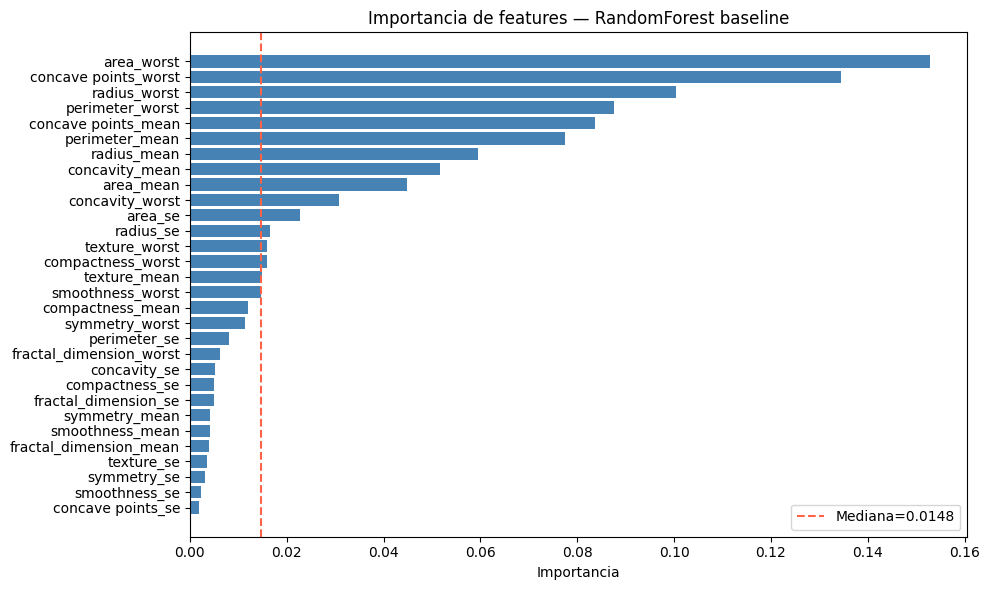

In [30]:
# --- 1. Importancia de features del modelo baseline ---
rf_importancias = RandomForestClassifier(max_depth=5, random_state=42)
rf_importancias.fit(X_train, y_train)

importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importancia": rf_importancias.feature_importances_
}).sort_values("importancia", ascending=False)

print("Importancia de features (RandomForest baseline):")
print(importancias.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importancias["feature"][::-1], importancias["importancia"][::-1], color="steelblue")
plt.axvline(importancias["importancia"].median(), color="tomato", linestyle="--",
            label=f"Mediana={importancias['importancia'].median():.4f}")
plt.title("Importancia de features — RandomForest baseline")
plt.xlabel("Importancia")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# --- 2. SelectFromModel — threshold=median ---
selector_sfm_median = SelectFromModel(estimator=rf_importancias, threshold="median")

selector_sfm_median.fit(X_train, y_train)

X_train_sfm_median = pd.DataFrame(
    selector_sfm_median.transform(X_train),
    columns=selector_sfm_median.get_feature_names_out()
)
X_test_sfm_median = pd.DataFrame(
    selector_sfm_median.transform(X_test),
    columns=selector_sfm_median.get_feature_names_out()
)

print(f"\nFeatures seleccionadas (mediana): {selector_sfm_median.get_feature_names_out().tolist()}")
print(f"Número de features: {X_train_sfm_median.shape[1]}")


Features seleccionadas (mediana): ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'radius_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']
Número de features: 15


In [35]:
# Regresión logística — requiere escalado
scaler = StandardScaler()
X_train_sfm_median_sc = scaler.fit_transform(X_train_sfm_median)
X_test_sfm_median_sc  = scaler.transform(X_test_sfm_median)

lr_median = LogisticRegression(max_iter=1000, random_state=42)

cv_sfm_median = cross_validate(
    lr_median, X_train_sfm_median_sc, y_train,
    cv=5,
    scoring="balanced_accuracy",
    return_train_score=True
)

print(f"\nTrain balanced_accuracy: {cv_sfm_median['train_score'].mean():.4f} ± {cv_sfm_median['train_score'].std():.4f}")
print(f"Val   balanced_accuracy: {cv_sfm_median['test_score'].mean():.4f} ± {cv_sfm_median['test_score'].std():.4f}")


Train balanced_accuracy: 0.9683 ± 0.0077
Val   balanced_accuracy: 0.9583 ± 0.0150


In [37]:
lr_median.fit(X_train_sfm_median_sc, y_train)
sfm_median_score = balanced_accuracy_score(y_test, lr_median.predict(X_test_sfm_median_sc))
sfm_median_score

0.9692460317460317

In [33]:
# --- 3. SelectFromModel — top 5 ---
selector_sfm_top5 = SelectFromModel(
    estimator=RandomForestClassifier(max_depth=5, random_state=42),
    max_features=5,
    threshold=-np.inf  # ignora threshold, selecciona solo por max_features
)
selector_sfm_top5.fit(X_train, y_train)

X_train_sfm_top5 = pd.DataFrame(
    selector_sfm_top5.transform(X_train),
    columns=selector_sfm_top5.get_feature_names_out()
)
X_test_sfm_top5 = pd.DataFrame(
    selector_sfm_top5.transform(X_test),
    columns=selector_sfm_top5.get_feature_names_out()
)

print(f"\nFeatures seleccionadas (top 5): {selector_sfm_top5.get_feature_names_out().tolist()}")


Features seleccionadas (top 5): ['concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [34]:
scaler_top5 = StandardScaler()
X_train_sfm_top5_sc = scaler_top5.fit_transform(X_train_sfm_top5)
X_test_sfm_top5_sc  = scaler_top5.transform(X_test_sfm_top5)

lr_top5 = LogisticRegression(max_iter=1000, random_state=42)

cv_sfm_top5 = cross_validate(
    lr_top5, X_train_sfm_top5_sc, y_train,
    cv=5,
    scoring="balanced_accuracy",
    return_train_score=True
)

print(f"\nTrain balanced_accuracy: {cv_sfm_top5['train_score'].mean():.4f} ± {cv_sfm_top5['train_score'].std():.4f}")
print(f"Val   balanced_accuracy: {cv_sfm_top5['test_score'].mean():.4f} ± {cv_sfm_top5['test_score'].std():.4f}")

lr_top5.fit(X_train_sfm_top5_sc, y_train)
sfm_top5_score = balanced_accuracy_score(y_test, lr_top5.predict(X_test_sfm_top5_sc))


Train balanced_accuracy: 0.9414 ± 0.0141
Val   balanced_accuracy: 0.9319 ± 0.0357


In [38]:
# --- Comparación final ---
print("\n=== COMPARACIÓN ===")
print(f"Baseline         (30 features): {baseline_score:.4f}")
print(f"Visual            (4 features): {visual_score:.4f}")
print(f"ANOVA            (10 features): {anova_score:.4f}")
print(f"RFE               (5 features): {rfe_score:.4f}")
print(f"SFM mediana  ({X_train_sfm_median.shape[1]} features): {sfm_median_score:.4f}")
print(f"SFM top 5     (5 features): {sfm_top5_score:.4f}")


=== COMPARACIÓN ===
Baseline         (30 features): 0.9643
Visual            (4 features): 0.9454
ANOVA            (10 features): 0.9405
RFE               (5 features): 0.9315
SFM mediana  (15 features): 0.9692
SFM top 5     (5 features): 0.9504


### Ejercicio EXTRA:

Investiga RFECV y obten el número optimo de features siguiendo esta técnica pero con el "balanced_accuracy" como métrica.

In [40]:


rfecv = RFECV(
    estimator=RandomForestClassifier(max_depth=5, random_state=42),
    step=1,
    cv=5,
    scoring="balanced_accuracy",
    min_features_to_select=1
)
rfecv.fit(X_train, y_train)

print(f"Número óptimo de features: {rfecv.n_features_}")
print(f"Features seleccionadas: {X_train.columns[rfecv.support_].tolist()}")

Número óptimo de features: 12
Features seleccionadas: ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst']


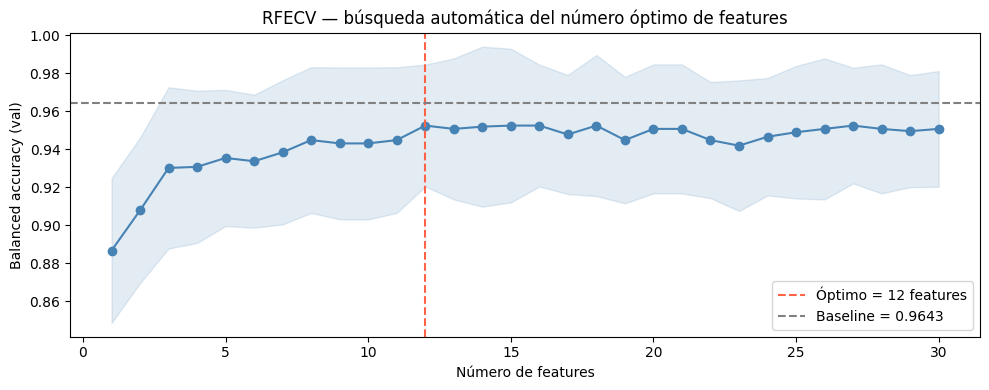

In [41]:
# Gráfico de balanced_accuracy vs número de features
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"],
         marker="o", color="steelblue")
plt.fill_between(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"] - rfecv.cv_results_["std_test_score"],
    rfecv.cv_results_["mean_test_score"] + rfecv.cv_results_["std_test_score"],
    alpha=0.15, color="steelblue"
)
plt.axvline(rfecv.n_features_, color="tomato", linestyle="--",
            label=f"Óptimo = {rfecv.n_features_} features")
plt.axhline(baseline_score, color="gray", linestyle="--",
            label=f"Baseline = {baseline_score:.4f}")
plt.xlabel("Número de features")
plt.ylabel("Balanced accuracy (val)")
plt.title("RFECV — búsqueda automática del número óptimo de features")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# Evaluamos en test
X_train_rfecv = pd.DataFrame(
    rfecv.transform(X_train),
    columns=X_train.columns[rfecv.support_]
)
X_test_rfecv = pd.DataFrame(
    rfecv.transform(X_test),
    columns=X_train.columns[rfecv.support_]
)

rf_rfecv = RandomForestClassifier(max_depth=5, random_state=42)

cv_rfecv = cross_validate(
    rf_rfecv, X_train_rfecv, y_train,
    cv=5,
    scoring="balanced_accuracy",
    return_train_score=True
)

print(f"\nTrain balanced_accuracy: {cv_rfecv['train_score'].mean():.4f} ± {cv_rfecv['train_score'].std():.4f}")
print(f"Val   balanced_accuracy: {cv_rfecv['test_score'].mean():.4f} ± {cv_rfecv['test_score'].std():.4f}")


Train balanced_accuracy: 0.9897 ± 0.0043
Val   balanced_accuracy: 0.9601 ± 0.0386


In [43]:
rf_rfecv.fit(X_train_rfecv, y_train)
rfecv_score = balanced_accuracy_score(y_test, rf_rfecv.predict(X_test_rfecv))

print("\n=== COMPARACIÓN FINAL ===")
print(f"Baseline         (30 features): {baseline_score:.4f}")
print(f"Visual            (4 features): {visual_score:.4f}")
print(f"ANOVA            (10 features): {anova_score:.4f}")
print(f"RFE               (5 features): {rfe_score:.4f}")
print(f"SFM mediana      (?? features): {sfm_median_score:.4f}")
print(f"SFM top 5         (5 features): {sfm_top5_score:.4f}")
print(f"RFECV  ({rfecv.n_features_:2d} features óptimas): {rfecv_score:.4f}")


=== COMPARACIÓN FINAL ===
Baseline         (30 features): 0.9643
Visual            (4 features): 0.9454
ANOVA            (10 features): 0.9405
RFE               (5 features): 0.9315
SFM mediana      (?? features): 0.9692
SFM top 5         (5 features): 0.9504
RFECV  (12 features óptimas): 0.9524
